<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Detection/ReBeat_Model_v17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We manage outliers for the training

#Load data

This code downloads and extracts three datasets from a public Zenodo repository into separate directories in the Colab environment. It first creates folders for raw data, filtered data, and expert annotations, then fetches the corresponding ZIP files from their URLs, saves them locally, and unzips their contents into the appropriate directories for further processing.

In [1]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

In [2]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from IPython.display import display
from google.colab import files

from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Bidirectional, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model v4


In [7]:
# ---- Parameters ----
subjects = [str(i) for i in range(1, 25)]
tasks = ['CW', 'BL']
fs = 250  # Hz
segment_len = 200
pre_r = int(0.2 * fs)   # 50 samples
post_r = int(0.6 * fs)  # 150 samples

all_segments = []
all_labels = []
all_labels_bcxo = []
all_rpeaks = []

for subject in subjects:
    for task in tasks:
        try:
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            annotation = sio.loadmat(path_annotation)

            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()
            annotations = annotation['annotPoints']  # [n_annotations, 4]

            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))

            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue

                ecg_segment = ecg_filtered[start:end]
                icg_segment = icg_filtered[start:end]
                if len(ecg_segment) != segment_len or len(icg_segment) != segment_len:
                    continue

                segment = np.stack((icg_segment, ecg_segment), axis=-1)  # [200, 2]

                for row in annotations:
                    b, c, x, o = row
                    if start <= b and o <= end:
                        rel_b = b - start
                        rel_c = c - start
                        rel_x = x - start
                        rel_o = o - start
                        all_segments.append(segment)
                        all_rpeaks.append(pre_r)  # R-peak index within the segment (always 50 in your setup)
                        all_labels.append([rel_b, rel_x, rel_o])           # For previous use
                        all_labels_bcxo.append([rel_b, rel_c, rel_x, rel_o])  # New variable
                        break  # avoid duplicate matches

            print(f"Loaded Subject {subject} Task {task}: {len(r_peaks)} R-peaks")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X = np.array(all_segments)  # [n_samples, 200, 2]
y = np.array(all_labels)    # [n_samples, 3] → B, X, O
y_bcxo = np.array(all_labels_bcxo)  # [n_samples, 4] → B, C, X, O

# ---- Normalize per channel, per sample ----
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X = (X - X_mean) / X_std

# ---- One-hot encode labels: classes = B, X, O ----
n_samples = y.shape[0]
n_classes = 3  # Only B, X, O
y_onehot = np.zeros((n_samples, segment_len, n_classes), dtype=np.float32)

for i in range(n_samples):
    for class_idx, t in enumerate(y[i]):  # B=0, X=1, O=2
        if 0 <= t < segment_len:
            y_onehot[i, t, class_idx] = 1.0

# ---- Save everything ----
np.save("X_icg_ecg_segments_bxo.npy", X)           # [n_samples, 200, 2]
np.save("y_icg_labels_bxo.npy", y)                 # [n_samples, 3]
np.save("y_icg_labels_bxo_onehot.npy", y_onehot)   # [n_samples, 200, 3]
r_peaks_aligned = np.array(all_rpeaks)  # [n_samples,]
np.save("r_peaks_in_segments.npy", r_peaks_aligned)

# ---- Preview ----
df_preview = pd.DataFrame(y[:10], columns=["B", "X", "O"])
print("\nSample annotation preview (relative to R-aligned segment):")
print(df_preview)

Loaded Subject 1 Task CW: 309 R-peaks
Loaded Subject 1 Task BL: 301 R-peaks
Loaded Subject 2 Task CW: 306 R-peaks
Loaded Subject 2 Task BL: 312 R-peaks
Loaded Subject 3 Task CW: 369 R-peaks
Loaded Subject 3 Task BL: 375 R-peaks
Loaded Subject 4 Task CW: 407 R-peaks
Loaded Subject 4 Task BL: 416 R-peaks
Skipping Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
Loaded Subject 5 Task BL: 404 R-peaks
Loaded Subject 6 Task CW: 339 R-peaks
Loaded Subject 6 Task BL: 355 R-peaks
Loaded Subject 7 Task CW: 326 R-peaks
Loaded Subject 7 Task BL: 342 R-peaks
Loaded Subject 8 Task CW: 389 R-peaks
Loaded Subject 8 Task BL: 387 R-peaks
Loaded Subject 9 Task CW: 408 R-peaks
Loaded Subject 9 Task BL: 400 R-peaks
Loaded Subject 10 Task CW: 318 R-peaks
Loaded Subject 10 Task BL: 314 R-peaks
Loaded Subject 11 Task CW: 430 R-peaks
Loaded Subject 11 Task BL: 391 R-peaks
Loaded Subject 12 Task CW: 339 R-peaks
Loaded Subject 12 Task BL: 359 R-peaks
Lo

In [8]:
import numpy as np

def detect_physiological_outliers(y_bcxo, r_peaks):
    """
    Returns a dictionary with boolean masks indicating outliers per point (B, C, X, O),
    based on expected temporal order between points.

    Parameters:
        y_bcxo: np.ndarray of shape (n_samples, 4) — true B, C, X, O sample indices
        r_peaks: np.ndarray of shape (n_samples,) — R peak index for each segment

    Returns:
        outlier_masks: dict with keys 'B', 'C', 'X', 'O', each mapping to a boolean array (True = outlier)
    """
    B = y_bcxo[:, 0]
    C = y_bcxo[:, 1]
    X = y_bcxo[:, 2]
    O = y_bcxo[:, 3]
    R = r_peaks

    outliers = {}

    outliers['B'] = (B < R) | (B > C)
    outliers['C'] = (C < B) | (C > X)
    outliers['X'] = (X < C) | (X > O)
    outliers['O'] = (O < X)

    return outliers
outliers = detect_physiological_outliers(y_bcxo, r_peaks_aligned)


for point in ['B', 'C', 'X', 'O']:
    count = np.sum(outliers[point])
    percent = 100 * count / len(y_bcxo)
    print(f"{point} outliers: {count} samples ({percent:.2f}%)")

B outliers: 24 samples (1.33%)
C outliers: 61 samples (3.38%)
X outliers: 61 samples (3.38%)
O outliers: 0 samples (0.00%)


In [9]:
# Create a boolean mask: True if the segment is valid (no outliers)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
X_clean = X[valid_mask]
y_clean = y[valid_mask]
y_bcxo_clean = y_bcxo[valid_mask]
y_onehot_clean = y_onehot[valid_mask]
r_peaks_clean = r_peaks_aligned[valid_mask]
np.save("X_clean_icg_ecg_segments_bxo.npy", X_clean)
np.save("y_clean_icg_labels_bxo.npy", y_clean)
np.save("y_clean_icg_labels_bxo_onehot.npy", y_onehot_clean)
np.save("y_clean_icg_labels_bcxo.npy", y_bcxo_clean)
np.save("r_peaks_clean_in_segments.npy", r_peaks_clean)
print(f"Kept {np.sum(valid_mask)} out of {len(y_bcxo)} segments ({np.mean(valid_mask) * 100:.2f}%)")

Kept 1720 out of 1805 segments (95.29%)


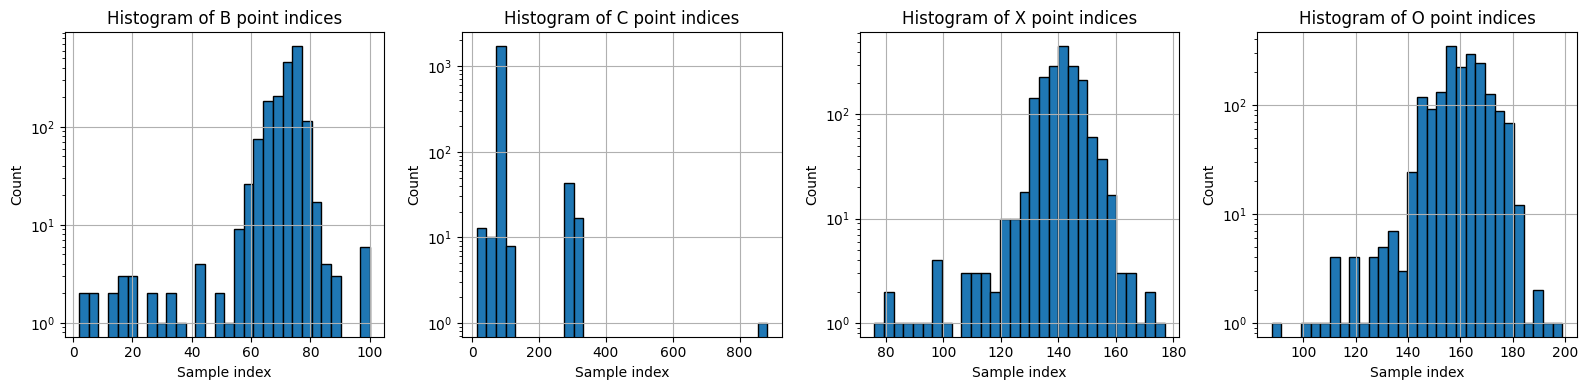

In [17]:
plt.figure(figsize=(16, 4))

# B point
plt.subplot(1, 4, 1)
b_values = y_bcxo[:, 0]
plt.hist(b_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of B point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# C point
plt.subplot(1, 4, 2)
c_values = y_bcxo[:, 1]
plt.hist(c_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of C point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# X point
plt.subplot(1, 4, 3)
x_values = y_bcxo[:, 2]
plt.hist(x_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of X point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# O point
plt.subplot(1, 4, 4)
o_values = y_bcxo[:, 3]
plt.hist(o_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of O point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()

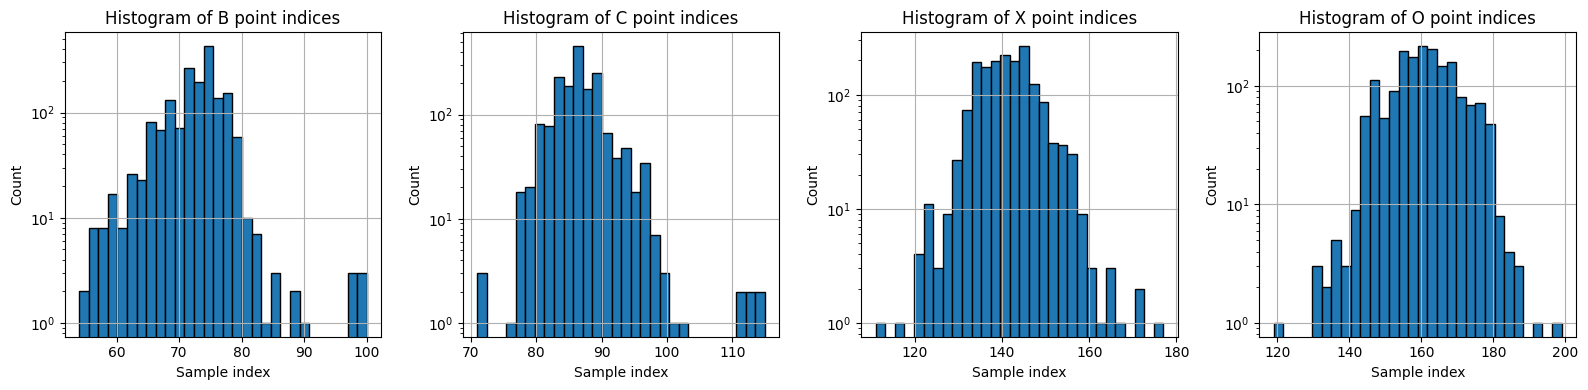

In [18]:
plt.figure(figsize=(16, 4))

# B point
plt.subplot(1, 4, 1)
b_values = y_bcxo_clean[:, 0]
plt.hist(b_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of B point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# C point
plt.subplot(1, 4, 2)
c_values = y_bcxo_clean[:, 1]
plt.hist(c_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of C point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# X point
plt.subplot(1, 4, 3)
x_values = y_bcxo_clean[:, 2]
plt.hist(x_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of X point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

# O point
plt.subplot(1, 4, 4)
o_values = y_bcxo_clean[:, 3]
plt.hist(o_values, bins=30, edgecolor='black')
plt.yscale('log')
plt.title("Histogram of O point indices")
plt.xlabel("Sample index")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
def augment_batch(X, y, noise_std=0.1, amp_range=(0.9, 1.1), max_shift=2):
    X_aug = np.copy(X)
    y_aug = np.copy(y)

    for i in range(X.shape[0]):
        # --- Gaussian noise ---a
        X_aug[i] += np.random.normal(0, noise_std, size=X[i].shape)

        # --- Amplitude scaling ---
        scale = np.random.uniform(*amp_range)
        X_aug[i] *= scale

        # --- Time shift ---
        shift = np.random.randint(-max_shift, max_shift + 1)
        if shift != 0:
            X_aug[i] = np.roll(X_aug[i], shift, axis=0)
            y_aug[i] = np.roll(y_aug[i], shift, axis=0)
            if shift > 0:
                y_aug[i, :shift] = 0
            else:
                y_aug[i, shift:] = 0

    return X_aug, y_aug


In [11]:
def build_model(input_shape=(200, 2), num_classes=3):
    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)

    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.3)(x)  # helps generalization
    x = Bidirectional(LSTM(32, return_sequences=True))(x)

    x = TimeDistributed(Dense(64, activation='relu'))(x)
    outputs = TimeDistributed(Dense(num_classes, activation='softmax'))(x)

    model = Model(inputs, outputs)
    return model

### Training

The commented sections correspond to the training process. They are commented out to avoid retraining the model every time the notebook is run. Instead, the trained model can be imported directly from GitHub.

In [25]:

# Load updated B-X-O data
X = np.load("X_clean_icg_ecg_segments_bxo.npy")           # shape: (n_samples, 200, 2)
y = np.load("y_clean_icg_labels_bxo_onehot.npy")          # shape: (n_samples, 200, 3)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Augment only training data
X_train_aug, y_train_aug = augment_batch(X_train, y_train)

# Build model for 3-class output
model = build_model(input_shape=(200, 2), num_classes=3)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.4261 - loss: 0.0129 - val_accuracy: 0.1875 - val_loss: 0.0033
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 908ms/step - accuracy: 0.2036 - loss: 0.0021 - val_accuracy: 0.3057 - val_loss: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 963ms/step - accuracy: 0.2963 - loss: 6.7003e-04 - val_accuracy: 0.3247 - val_loss: 5.3420e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 884ms/step - accuracy: 0.3245 - loss: 3.0257e-04 - val_accuracy: 0.2823 - val_loss: 4.4089e-04
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 944ms/step - accuracy: 0.2930 - loss: 2.4424e-04 - val_accuracy: 0.3522 - val_loss: 3.9702e-04
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 858ms/step - accuracy: 0.3181 - loss: 2.7001e-04 - val_accuracy: 0.3496 - val_loss: 4.8085e-04
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 926ms/step - accuracy: 0.3776 - loss: 2.6012e-04 - val_accuracy: 0.3786 - val_loss: 3.9266e-04
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 902ms/step - accur

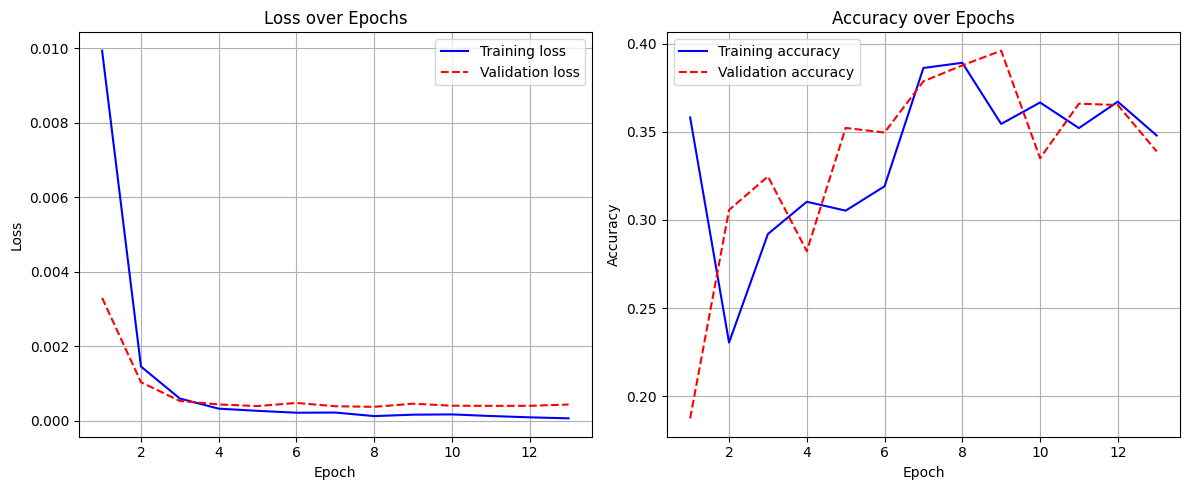

In [37]:

# Extract training history
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

# Plot loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r--', label='Validation loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'b-', label='Training accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Using the model

In [26]:
def extract_predicted_points(y_pred):
    """
    Extract time indices of predicted B, X, and O points.

    Input:
        y_pred: np.array of shape (n_samples, 200, 3) — softmax outputs
    Returns:
        pred_points: np.array of shape (n_samples, 3) — time indices for B, X, O
    """
    n_samples = y_pred.shape[0]
    pred_points = np.zeros((n_samples, 3), dtype=int)  # B, X, O

    for i in range(3):  # class 0 = B, 1 = X, 2 = O
        pred_points[:, i] = np.argmax(y_pred[:, :, i], axis=1)

    return pred_points

In [15]:
#model = files.upload()

In [27]:
#model = load_model('model_v4.keras')

y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
predicted_points = extract_predicted_points(y_pred)

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 467ms/step


In [28]:
def plot_prediction_vs_true(X_sample, y_true_onehot, y_pred_onehot, sample_index=0, fs=250, pre_r=50):
    """
    Visualizes true vs predicted labels on top of ICG signal (for B, X, O only)
    """
    signal = X_sample[sample_index, :, 0]  # ICG signal
    time_steps = np.arange(signal.shape[0])
    time_ms = (time_steps - pre_r) * 1000 / fs

    labels = ["B", "X", "O"]
    colors = ["blue", "green", "red"]

    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, signal, label='ICG signal', color='black', linewidth=1)

    for class_id in range(3):
        true_t = np.argmax(y_true_onehot[sample_index, :, class_id])
        pred_t = np.argmax(y_pred_onehot[sample_index, :, class_id])

        plt.axvline((true_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='-', label=f'True {labels[class_id]}')
        plt.axvline((pred_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='--', alpha=0.6, label=f'Pred {labels[class_id]}')

    plt.title(f"Sample {sample_index}: True vs Predicted Characteristic Points (B, X, O)")
    plt.xlabel("Time (ms)")
    plt.ylabel("ICG amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


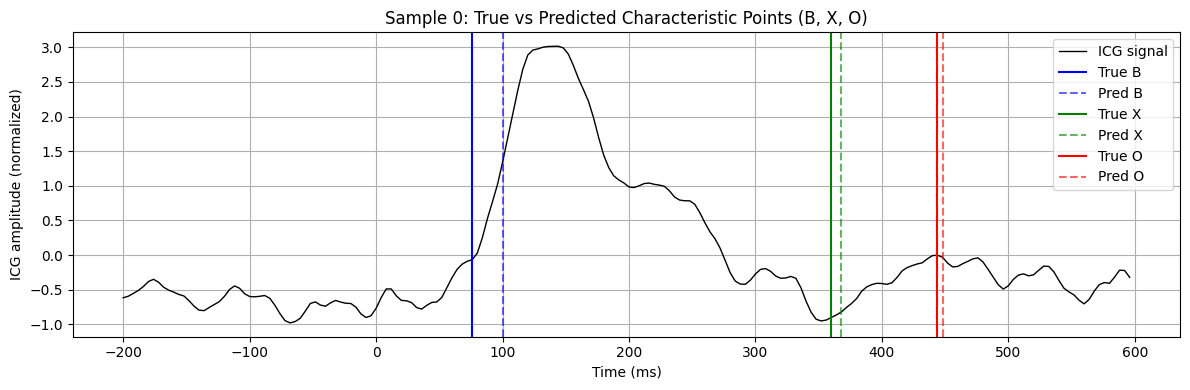

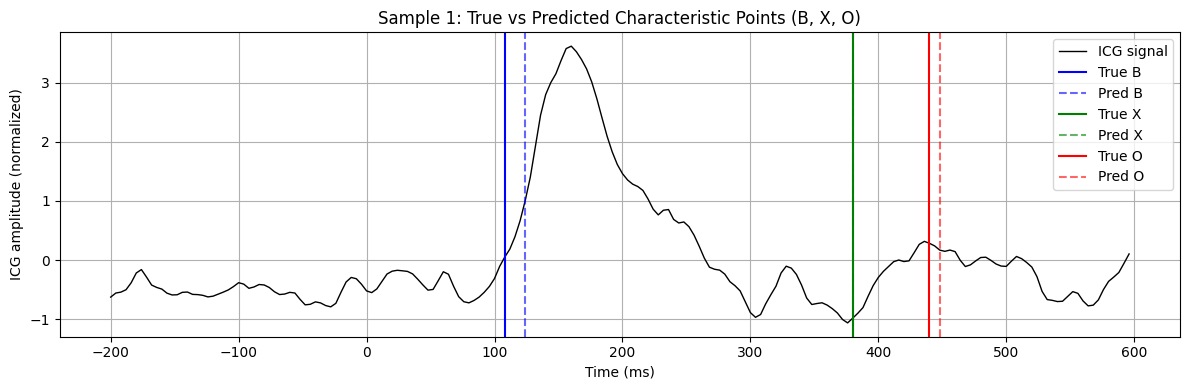

In [29]:
for i in range(0,2):
  plot_prediction_vs_true(X_val, y_val, y_pred, sample_index=i)

### Evaluation of the performance of the model

Mean Absolute Error (MAE) measures, on average, how far the model's predictions are from the true values, ignoring the direction.

In [30]:
def compute_point_errors(y_true_onehot, y_pred_softmax, fs=250, unit="samples"):
    """
    Computes absolute error for each point type (B, X, O).

    Parameters:
        y_true_onehot: (n_samples, 200, 3) — one-hot encoded true labels
        y_pred_softmax: (n_samples, 200, 3) — softmax predictions
        fs: sampling frequency (Hz)
        unit: 'samples' or 'ms'

    Returns:
        Dictionary of mean absolute error per point and overall mean.
    """
    y_true_idx = np.argmax(y_true_onehot, axis=1)   # (n_samples, 3)
    y_pred_idx = np.argmax(y_pred_softmax, axis=1)  # (n_samples, 3)

    sample_diff = np.abs(y_pred_idx - y_true_idx)

    if unit == "ms":
        diff = (sample_diff * 1000) / fs
    else:
        diff = sample_diff

    labels = ['B', 'X', 'O']
    errors = {lbl: diff[:, i].mean() for i, lbl in enumerate(labels)}
    errors['mean'] = diff.mean()

    return errors

In [31]:
# Predict
y_pred = model.predict(X_val)  # shape: (n_samples, 200, 3)

# Compute point-wise errors
errors = compute_point_errors(y_val, y_pred, fs=250, unit="samples")

# Display results
for point, err in errors.items():
    print(f"{point} point error: {err:.2f} samples")
    print(f"{point} point error: {(err/fs)*1000:.2f} ms")


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
B point error: 4.07 samples
B point error: 16.27 ms
X point error: 3.04 samples
X point error: 12.17 ms
O point error: 3.85 samples
O point error: 15.42 ms
mean point error: 3.66 samples
mean point error: 14.62 ms


In [36]:
model.save('model_v17.keras')  # Saves the full model (architecture + weights + optimizer)
from google.colab import files
files.download('model_v17.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import numpy as np

def evaluate_point_detection(y_true_onehot, y_pred_softmax, fs=250, tolerance=5):
    """
    Computes evaluation metrics for B/X/O point detection using one-hot ground truth
    and softmax predictions.

    Parameters:
        y_true_onehot: (n_samples, 200, 3) — one-hot true labels
        y_pred_softmax: (n_samples, 200, 3) — model softmax outputs
        fs: sampling frequency (Hz)
        tolerance: max error (in samples) to consider prediction correct

    Returns:
        metrics: dict of precision/recall/F1/specificity/gmean per point
        interval_metrics: dict of inter-point and beat-to-beat intervals (true + pred)
    """
    # Get time indices of the true and predicted labels
    y_true_idx = np.argmax(y_true_onehot, axis=1)       # (n_samples, 3)
    y_pred_idx = np.argmax(y_pred_softmax, axis=1)      # (n_samples, 3)

    errors = y_pred_idx - y_true_idx
    abs_errors = np.abs(errors)

    metrics = {}
    labels = ['B', 'X', 'O']
    n_samples = y_true_onehot.shape[0]

    for i, label in enumerate(labels):
        err = errors[:, i]
        abs_err = abs_errors[:, i]

        mae = abs_err.mean()
        bias = err.mean()
        std = err.std()
        within_tol = np.mean(abs_err <= tolerance) * 100

        TP = np.sum(abs_err <= tolerance)
        FP = np.sum(abs_err > tolerance)
        FN = 0  # one prediction per beat
        TN = n_samples - FP

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        gmean = np.sqrt(recall * specificity)

        metrics[label] = {
            'mae_samples': mae,
            'mae_ms': mae * 1000 / fs,
            'bias_samples': bias,
            'std_samples': std,
            f'within_{tolerance}_samples': within_tol,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1': f1,
            'gmean': gmean
        }

    # Inter-point intervals (within beat)
    X_B_true = y_true_idx[:, 1] - y_true_idx[:, 0]
    O_X_true = y_true_idx[:, 2] - y_true_idx[:, 1]
    X_B_pred = y_pred_idx[:, 1] - y_pred_idx[:, 0]
    O_X_pred = y_pred_idx[:, 2] - y_pred_idx[:, 1]

    # Beat-to-beat intervals (between beats)
    BB_true = np.diff(y_true_idx[:, 0])
    XX_true = np.diff(y_true_idx[:, 1])
    OO_true = np.diff(y_true_idx[:, 2])

    BB_pred = np.diff(y_pred_idx[:, 0])
    XX_pred = np.diff(y_pred_idx[:, 1])
    OO_pred = np.diff(y_pred_idx[:, 2])

    interval_metrics = {
        'X-B_true_mean_ms': np.mean(X_B_true) * 1000 / fs,
        'X-B_pred_mean_ms': np.mean(X_B_pred) * 1000 / fs,
        'O-X_true_mean_ms': np.mean(O_X_true) * 1000 / fs,
        'O-X_pred_mean_ms': np.mean(O_X_pred) * 1000 / fs,

        'BB_true_mean_ms': np.mean(BB_true) * 1000 / fs,
        'XX_true_mean_ms': np.mean(XX_true) * 1000 / fs,
        'OO_true_mean_ms': np.mean(OO_true) * 1000 / fs,

        'BB_pred_mean_ms': np.mean(BB_pred) * 1000 / fs,
        'XX_pred_mean_ms': np.mean(XX_pred) * 1000 / fs,
        'OO_pred_mean_ms': np.mean(OO_pred) * 1000 / fs,

        'BB_true_std_ms': np.std(BB_true) * 1000 / fs,
        'XX_true_std_ms': np.std(XX_true) * 1000 / fs,
        'OO_true_std_ms': np.std(OO_true) * 1000 / fs,

        'BB_pred_std_ms': np.std(BB_pred) * 1000 / fs,
        'XX_pred_std_ms': np.std(XX_pred) * 1000 / fs,
        'OO_pred_std_ms': np.std(OO_pred) * 1000 / fs,
    }

    return metrics, interval_metrics

In [33]:
# Predict
y_pred = model.predict(X_val)

# Evaluate
metrics, intervals = evaluate_point_detection(y_val, y_pred,fs=250, tolerance=5)

# Display results
for point, values in metrics.items():
    print(f"\n=== {point} point ===")
    for k, v in values.items():
        print(f"{k}: {v:.4f}")

print("\n=== Timing Intervals ===")
for k, v in intervals.items():
    print(f"{k}: {v:.2f} ms")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step

=== B point ===
mae_samples: 4.0669
mae_ms: 16.2674
bias_samples: 1.4506
std_samples: 5.6500
within_5_samples: 79.6512
precision: 0.7965
recall: 1.0000
specificity: 0.7965
f1: 0.8867
gmean: 0.8925

=== X point ===
mae_samples: 3.0436
mae_ms: 12.1744
bias_samples: -0.0145
std_samples: 11.9904
within_5_samples: 92.1512
precision: 0.9215
recall: 1.0000
specificity: 0.9215
f1: 0.9592
gmean: 0.9600

=== O point ===
mae_samples: 3.8547
mae_ms: 15.4186
bias_samples: 0.5988
std_samples: 10.2655
within_5_samples: 85.1744
precision: 0.8517
recall: 1.0000
specificity: 0.8517
f1: 0.9199
gmean: 0.9229

=== Timing Intervals ===
X-B_true_mean_ms: 274.16 ms
X-B_pred_mean_ms: 268.30 ms
O-X_true_mean_ms: 78.10 ms
O-X_pred_mean_ms: 80.56 ms
BB_true_mean_ms: 0.06 ms
XX_true_mean_ms: -0.02 ms
OO_true_mean_ms: -0.07 ms
BB_pred_mean_ms: 0.02 ms
XX_pred_mean_ms: -0.05 ms
OO_pred_mean_ms: -0.02 ms
BB_true_std_ms: 31.12 ms
XX_true_std_ms: 35.26 ms
OO_true_std_ms: 53.22 

#Evaluation on unannotated data

Detected 297 R-peaks
Extracted 295 valid segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step


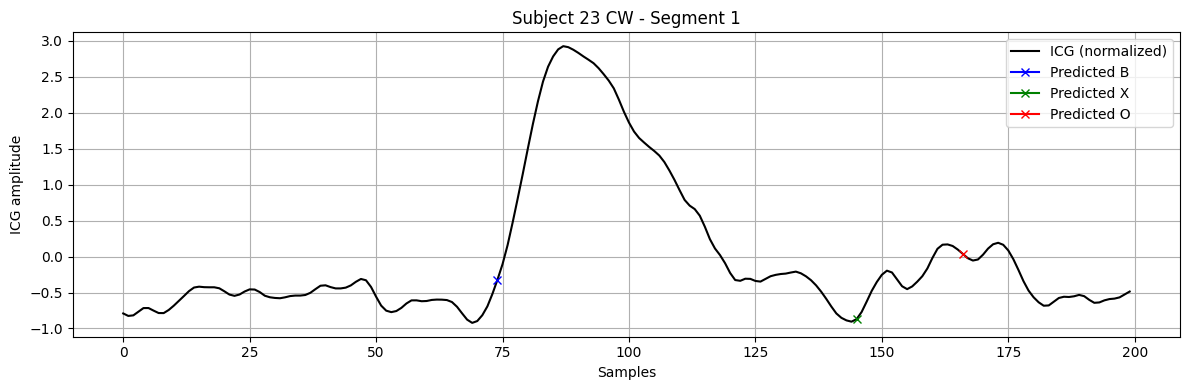

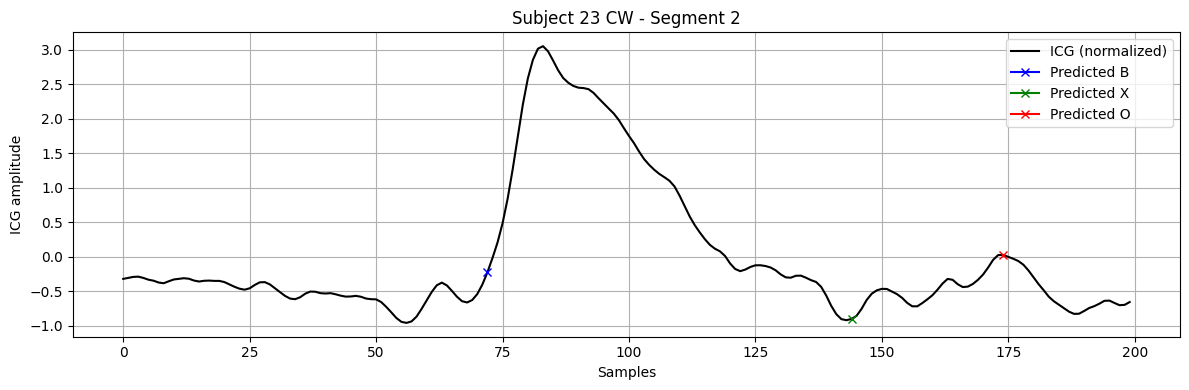

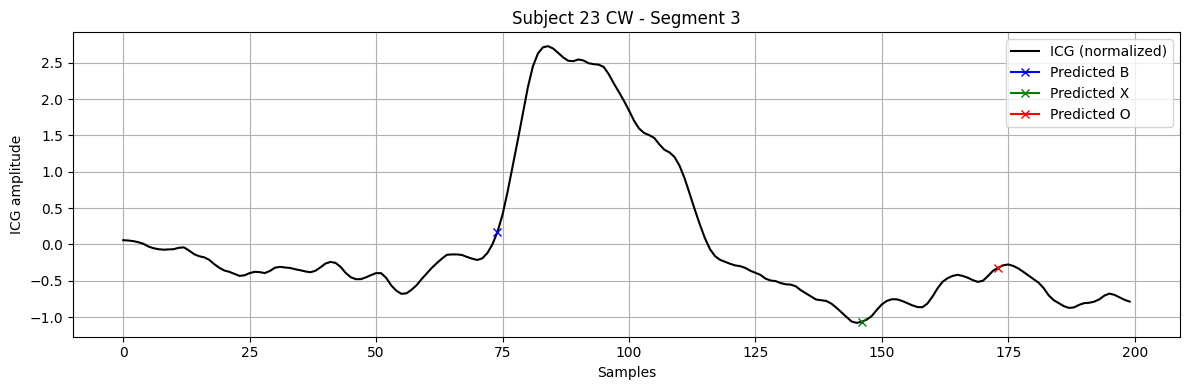

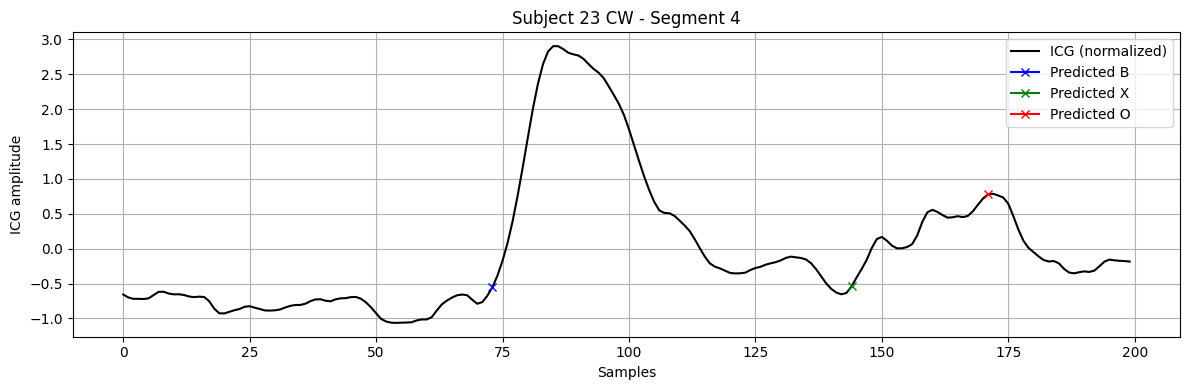

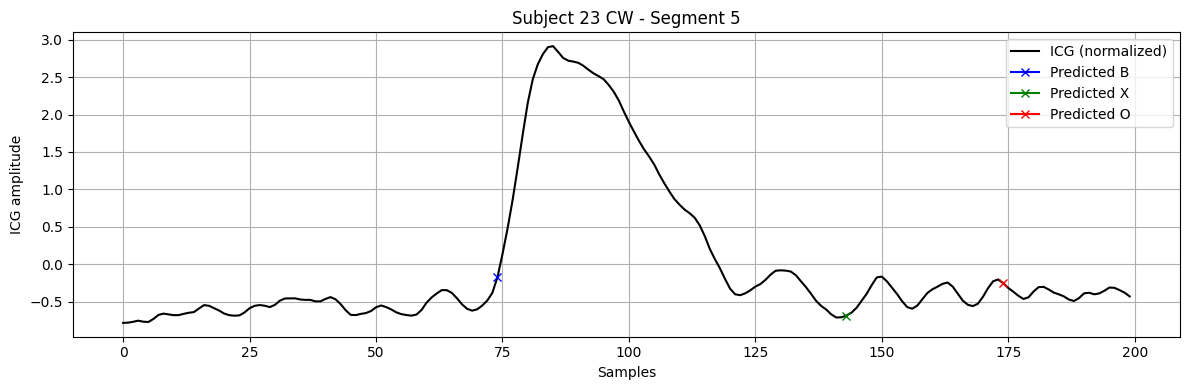

In [35]:
# ---- Load data ----
subject = '23'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # 250 Hz

# ---- R-peak detection ----
r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG and ECG ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r

segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        icg_seg = icg_filtered[start:end]
        ecg_seg = ecg_filtered[start:end]
        if len(icg_seg) == segment_len:
            # Normalize per segment
            icg_seg = (icg_seg - np.mean(icg_seg)) / (np.std(icg_seg) + 1e-8)
            ecg_seg = (ecg_seg - np.mean(ecg_seg)) / (np.std(ecg_seg) + 1e-8)

            segment = np.stack((icg_seg, ecg_seg), axis=-1)  # (200, 2)
            segments.append(segment)
            valid_r_peaks.append(r)

print(f"Extracted {len(segments)} valid segments")

X_input = np.array(segments)  # (n_segments, 200, 2)

# ---- Load model and predict ----
#model = load_model("model_v4.keras", compile=False)  # 3-class model
y_pred = model.predict(X_input)  # (n, 200, 3)

# ---- Extract predicted points ----
pred_idx = np.argmax(y_pred, axis=1)  # (n, 3), class-wise argmax over time

# ---- Refine predicted points ----
#refined_predicted_points = refine_predicted_points(X_val, predicted_points)

# ---- Plot ----
for i in range(min(5, len(X_input))):
    signal = X_input[i, :, 0]  # ICG only
    plt.figure(figsize=(12, 4))
    plt.plot(signal, label='ICG (normalized)', color='black')
    labels = ['B', 'X', 'O']
    colors = ['blue', 'green', 'red']

    for class_id, label, color in zip(range(3), labels, colors):
        # Predicted point
        pred = pred_idx[i, class_id]
        if 0 <= pred < segment_len:
            plt.plot(pred, signal[pred], marker='x', color=color, label=f'Predicted {label}')

        # Refined point (only for O)
        # if label == 'O':
        #     refined = refined_predicted_points[i, class_id]
        #     if 0 <= refined < segment_len:
        #         plt.plot(refined, signal[refined], marker='o', color=color, linestyle='None', label=f'Refined {label}')

    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [40]:
import numpy as np
from scipy.io import loadmat
from scipy.signal import find_peaks
from tensorflow.keras.models import load_model

# ---- Parameters ----
subjects = [str(i) for i in range(1, 25)]
tasks = ['CW', 'BL']
fs = 250  # Hz
pre_r = int(0.2 * fs)   # 50 samples
post_r = int(0.6 * fs)  # 150 samples
segment_len = pre_r + post_r  # 200

all_segments = []
all_labels_bcxo = []
segment_sources = []

for subject in subjects:
    for task in tasks:
        try:
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = loadmat(path_filtered)
            annotation = loadmat(path_annotation)

            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()
            annotations = annotation['annotPoints']  # [n_annotations, 4]

            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))
            print(f"Subject {subject} Task {task}: Detected {len(r_peaks)} R-peaks")

            for idx, r in enumerate(r_peaks):
                start = r - pre_r
                end = r + post_r
                if start < 0 or end >= len(icg_filtered):
                    continue

                for row in annotations:
                    b, c, x, o = row
                    if start <= b and o <= end:
                        rel_b = b - start
                        rel_c = c - start
                        rel_x = x - start
                        rel_o = o - start

                        icg_seg = icg_filtered[start:end]
                        ecg_seg = ecg_filtered[start:end]
                        if len(icg_seg) == segment_len:
                            # Normalize per segment
                            icg_seg = (icg_seg - np.mean(icg_seg)) / (np.std(icg_seg) + 1e-8)
                            ecg_seg = (ecg_seg - np.mean(ecg_seg)) / (np.std(ecg_seg) + 1e-8)
                            segment = np.stack((icg_seg, ecg_seg), axis=-1)

                            all_segments.append(segment)
                            all_labels_bcxo.append([rel_b, rel_c, rel_x, rel_o])
                            segment_sources.append((subject, task, idx))
                            break  # only use the first valid annotation
        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

print(f"\nTotal extracted segments: {len(all_segments)}")

# ---- Convert to NumPy arrays ----
X_input = np.array(all_segments)          # [n_samples, 200, 2]
y_bcxo = np.array(all_labels_bcxo)        # [n_samples, 4]
segment_sources = np.array(segment_sources)
r_peaks_aligned = np.full(len(y_bcxo), pre_r)  # R index in all segments

# ---- Detect physiological outliers ----
outliers = detect_physiological_outliers(y_bcxo, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])

# ---- Apply outlier mask ----
X_input = X_input[valid_mask]
y_bcxo = y_bcxo[valid_mask]
segment_sources = segment_sources[valid_mask]
print(f"Kept {np.sum(valid_mask)} of {len(valid_mask)} segments ({np.mean(valid_mask)*100:.2f}%) after outlier removal.")

# ---- Predict using trained model ----
model = load_model("model_v17.keras", compile=False)  # Output shape (200, 3)
y_pred = model.predict(X_input)  # Shape: (n_samples, 200, 3)

# ---- Extract predicted B, X, O indices ----
pred_idx = np.argmax(y_pred, axis=1)  # Shape: (n_samples, 3)

Subject 1 Task CW: Detected 309 R-peaks
Subject 1 Task BL: Detected 301 R-peaks
Subject 2 Task CW: Detected 306 R-peaks
Subject 2 Task BL: Detected 312 R-peaks
Subject 3 Task CW: Detected 369 R-peaks
Subject 3 Task BL: Detected 375 R-peaks
Subject 4 Task CW: Detected 407 R-peaks
Subject 4 Task BL: Detected 416 R-peaks
Skipping Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
Subject 5 Task BL: Detected 404 R-peaks
Subject 6 Task CW: Detected 339 R-peaks
Subject 6 Task BL: Detected 355 R-peaks
Subject 7 Task CW: Detected 326 R-peaks
Subject 7 Task BL: Detected 342 R-peaks
Subject 8 Task CW: Detected 389 R-peaks
Subject 8 Task BL: Detected 387 R-peaks
Subject 9 Task CW: Detected 408 R-peaks
Subject 9 Task BL: Detected 400 R-peaks
Subject 10 Task CW: Detected 318 R-peaks
Subject 10 Task BL: Detected 314 R-peaks
Subject 11 Task CW: Detected 430 R-peaks
Subject 11 Task BL: Detected 391 R-peaks
Subject 12 Task CW: Detected 339 R-pea

# C point detection

In [41]:
def detect_c_peak_after_r(icg_segments, predicted_bxo, offset=50, fs=250):
    """
    Detect C peaks within each ICG segment between R-peak (offset) and R + 100 ms.

    Parameters:
        icg_segments: np.array of shape (n_segments, segment_len)
        predicted_bxo: np.array of shape (n_segments, 3) — [B, X, O]
        offset: int, R-peak index in each segment (usually pre_r * fs)
        fs: int, sampling frequency in Hz (e.g., 250)

    Returns:
        predicted_b_c_x_o: np.array of shape (n_segments, 4)
    """
    c_indices = []
    window_length = int(0.3 * fs)  # 100 ms in samples

    for i in range(len(icg_segments)):
        seg = icg_segments[i]
        end_idx = min(offset + window_length, len(seg))  # avoid going out of bounds
        search_window = seg[offset:end_idx]

        if len(search_window) > 0:
            c_rel = np.argmax(search_window)  #it looks for the highest point in relative points
            c = offset + c_rel
        else:
            c = offset  # fallback to R-peak if window is empty

        c_indices.append(c)

    c_indices = np.array(c_indices)
    predicted_b_c_x_o = np.insert(predicted_bxo, 1, c_indices, axis=1)
    return predicted_b_c_x_o

In [42]:
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=5):
    """
    Plots ICG segments and marks predicted B, C, X, O points.
    """
    labels = ['B', 'C', 'X', 'O']
    colors = ['blue', 'orange', 'green', 'red']

    plt.figure(figsize=(15, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')

        for j, (label_name, color) in enumerate(zip(labels, colors)):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=color, label=f'Predicted {label_name}')

        plt.title(f'Segment {i+1} — Predicted Points (B, C, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        if i == 0:
            plt.legend()  # only on first plot
        plt.grid(True)

    plt.tight_layout()
    plt.show()

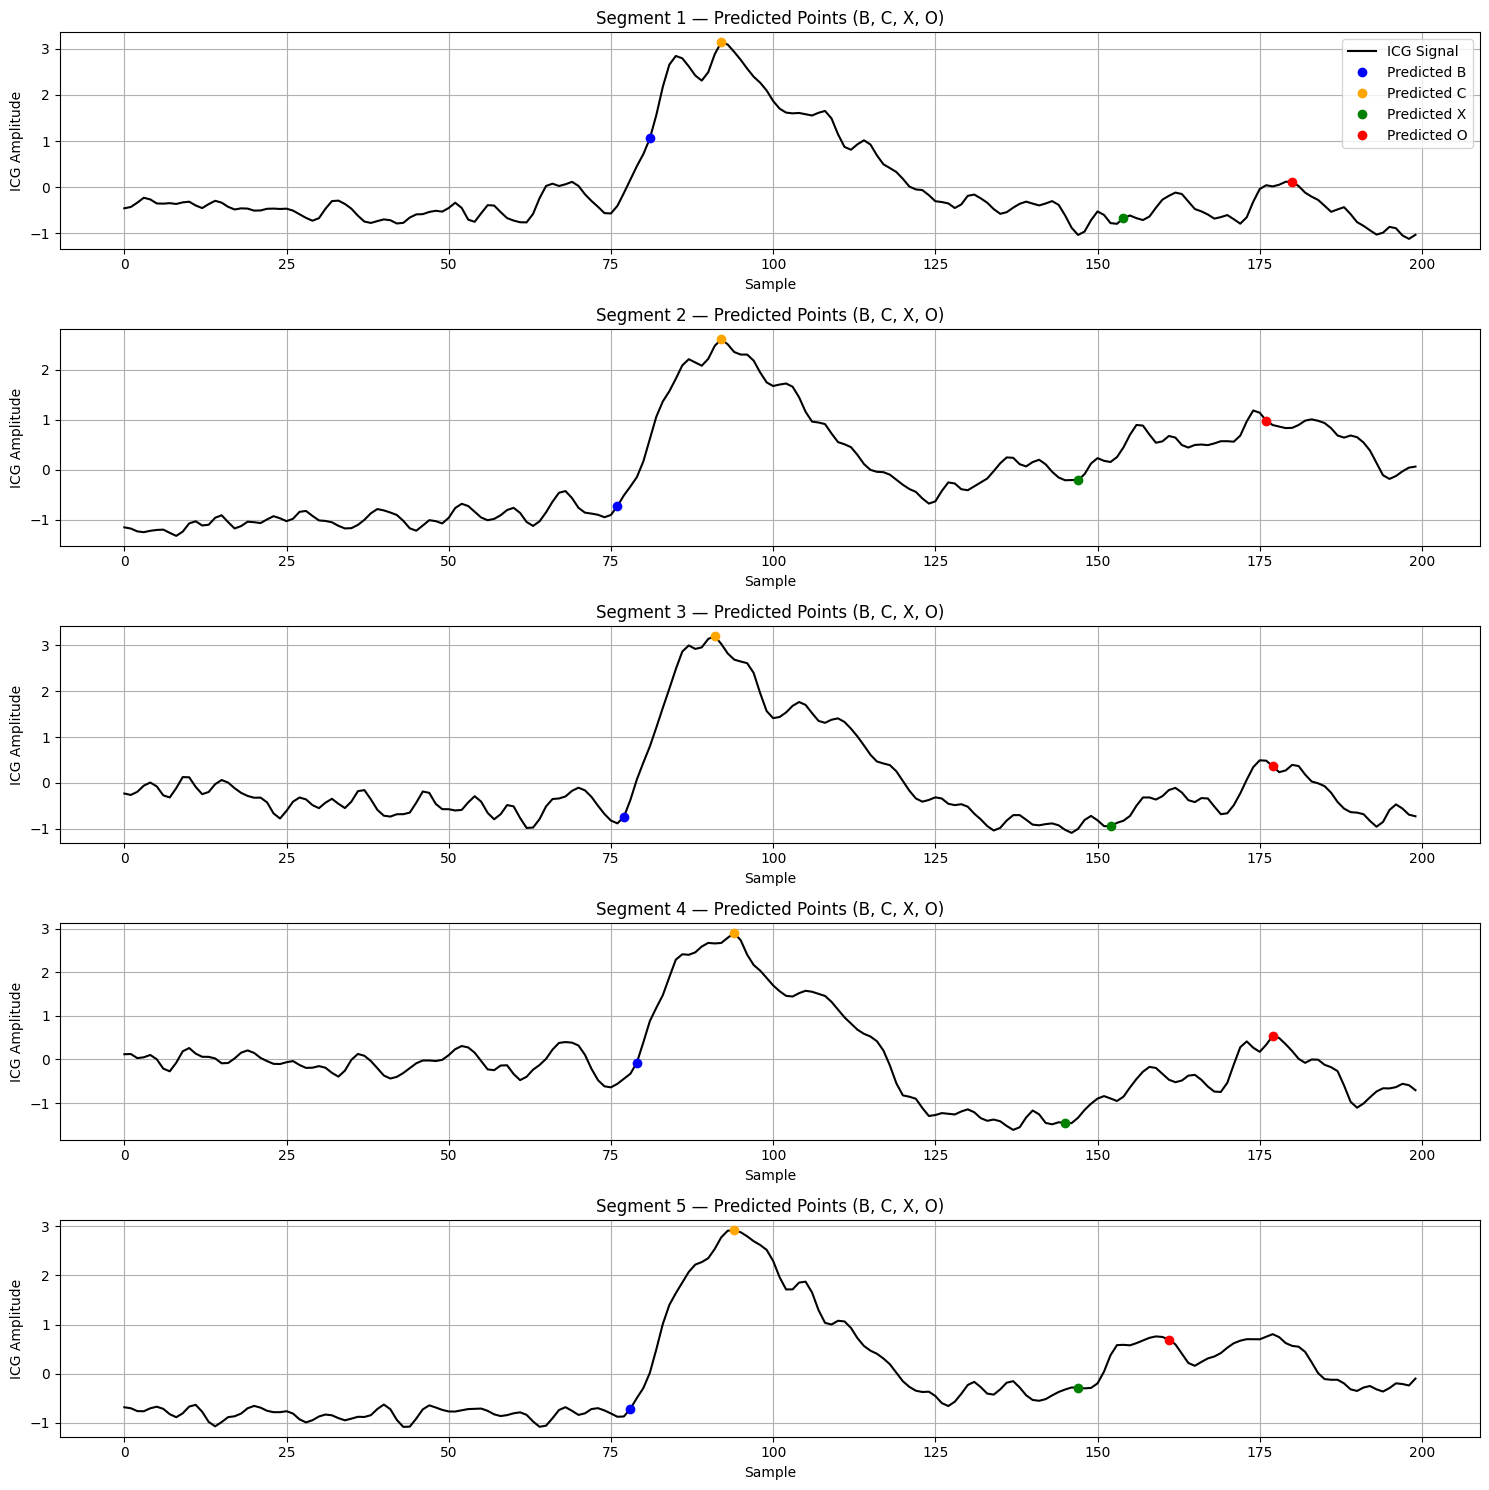

In [43]:
fs = 250
offset = int(0.2 * fs)  # 50 if fs = 250 Hz

predicted_bxo = extract_predicted_points(y_pred)  # shape: (n_segments, 3)
predicted_b_c_x_o = detect_c_peak_after_r(X_input[:, :, 0], predicted_bxo) #we are using the refined points

plot_icg_with_predicted_points(X_input[:, :, 0], predicted_b_c_x_o)

In [44]:
import numpy as np

def evaluate_point_detection_from_indices(y_true_idx, y_pred_idx, fs=250, tolerance=5, c_outlier_thresh_ms=50):
    """
    Evaluates B, C, X, O point detection with optional outlier filtering for point C.

    Parameters:
        y_true_idx: (n_samples, 4) — true sample indices for B, C, X, O
        y_pred_idx: (n_samples, 4) — predicted sample indices for B, C, X, O
        fs: sampling frequency (Hz)
        tolerance: number of samples within which a prediction is considered correct
        c_outlier_thresh_ms: max allowed error in ms for C-point (outlier threshold)

    Returns:
        metrics: dict with MAE, precision, etc. per point
        interval_metrics: dict with inter-point and beat-to-beat stats
    """
    y_true_idx = np.asarray(y_true_idx)
    y_pred_idx = np.asarray(y_pred_idx)

    errors = y_pred_idx - y_true_idx
    abs_errors = np.abs(errors)
    abs_errors_ms = abs_errors * 1000 / fs

    metrics = {}
    labels = ['B', 'C', 'X', 'O']
    n_samples = y_true_idx.shape[0]

    for i, label in enumerate(labels):
        err = errors[:, i]
        abs_err = abs_errors[:, i]
        abs_err_ms = abs_errors_ms[:, i]

        if label == 'C':
            mask = abs_err_ms <= c_outlier_thresh_ms
            if np.any(mask):
                err = err[mask]
                abs_err = abs_err[mask]
            else:
                err = np.array([0.0])
                abs_err = np.array([0.0])

        mae = abs_err.mean()
        bias = err.mean()
        std = err.std()
        within_tol = np.mean(abs_err <= tolerance) * 100

        TP = np.sum(abs_err <= tolerance)
        FP = np.sum(abs_err > tolerance)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        f1 = 2 * precision / (1 + precision) if precision > 0 else 0
        gmean = np.sqrt(precision)

        metrics[label] = {
            'mae_samples': mae,
            'mae_ms': mae * 1000 / fs,
            'bias_samples': bias,
            'std_samples': std,
            f'within_{tolerance}_samples': within_tol,
            'precision': precision,
            'f1': f1,
            'gmean': gmean
        }

    # Intervals (same as before, no outlier filtering)
    C_B_true = y_true_idx[:, 1] - y_true_idx[:, 0]
    X_B_true = y_true_idx[:, 2] - y_true_idx[:, 0]
    O_X_true = y_true_idx[:, 3] - y_true_idx[:, 2]

    C_B_pred = y_pred_idx[:, 1] - y_pred_idx[:, 0]
    X_B_pred = y_pred_idx[:, 2] - y_pred_idx[:, 0]
    O_X_pred = y_pred_idx[:, 3] - y_pred_idx[:, 2]

    BB_true = np.diff(y_true_idx[:, 0])
    XX_true = np.diff(y_true_idx[:, 2])
    OO_true = np.diff(y_true_idx[:, 3])

    BB_pred = np.diff(y_pred_idx[:, 0])
    XX_pred = np.diff(y_pred_idx[:, 2])
    OO_pred = np.diff(y_pred_idx[:, 3])

    interval_metrics = {
        'C-B_true_mean_ms': np.mean(C_B_true) * 1000 / fs,
        'C-B_pred_mean_ms': np.mean(C_B_pred) * 1000 / fs,
        'X-B_true_mean_ms': np.mean(X_B_true) * 1000 / fs,
        'X-B_pred_mean_ms': np.mean(X_B_pred) * 1000 / fs,
        'O-X_true_mean_ms': np.mean(O_X_true) * 1000 / fs,
        'O-X_pred_mean_ms': np.mean(O_X_pred) * 1000 / fs,

        'BB_true_mean_ms': np.mean(BB_true) * 1000 / fs,
        'XX_true_mean_ms': np.mean(XX_true) * 1000 / fs,
        'OO_true_mean_ms': np.mean(OO_true) * 1000 / fs,

        'BB_pred_mean_ms': np.mean(BB_pred) * 1000 / fs,
        'XX_pred_mean_ms': np.mean(XX_pred) * 1000 / fs,
        'OO_pred_mean_ms': np.mean(OO_pred) * 1000 / fs,

        'BB_true_std_ms': np.std(BB_true) * 1000 / fs,
        'XX_true_std_ms': np.std(XX_true) * 1000 / fs,
        'OO_true_std_ms': np.std(OO_true) * 1000 / fs,

        'BB_pred_std_ms': np.std(BB_pred) * 1000 / fs,
        'XX_pred_std_ms': np.std(XX_pred) * 1000 / fs,
        'OO_pred_std_ms': np.std(OO_pred) * 1000 / fs,
    }

    return metrics, interval_metrics

In [45]:

# Evaluate
metrics, intervals = evaluate_point_detection_from_indices(
    y_true_idx=y_bcxo,
    y_pred_idx=predicted_b_c_x_o,
    fs=250,
    tolerance=5,
    c_outlier_thresh_ms=50
)
# Display results
for point, values in metrics.items():
    print(f"\n=== {point} point ===")
    for k, v in values.items():
        print(f"{k}: {v:.4f}")

print("\n=== Timing Intervals ===")
for k, v in intervals.items():
    print(f"{k}: {v:.2f} ms")


=== B point ===
mae_samples: 4.1831
mae_ms: 16.7326
bias_samples: 1.2273
std_samples: 6.0871
within_5_samples: 78.8953
precision: 0.7890
f1: 0.8820
gmean: 0.8882

=== C point ===
mae_samples: 0.9761
mae_ms: 3.9043
bias_samples: -0.9586
std_samples: 0.4416
within_5_samples: 99.9416
precision: 0.9994
f1: 0.9997
gmean: 0.9997

=== X point ===
mae_samples: 2.5023
mae_ms: 10.0093
bias_samples: 0.0744
std_samples: 8.9453
within_5_samples: 93.9535
precision: 0.9395
f1: 0.9688
gmean: 0.9693

=== O point ===
mae_samples: 3.4907
mae_ms: 13.9628
bias_samples: 0.8686
std_samples: 8.1610
within_5_samples: 85.2907
precision: 0.8529
f1: 0.9206
gmean: 0.9235

=== Timing Intervals ===
C-B_true_mean_ms: 56.90 ms
C-B_pred_mean_ms: 48.24 ms
X-B_true_mean_ms: 274.76 ms
X-B_pred_mean_ms: 270.15 ms
O-X_true_mean_ms: 78.34 ms
O-X_pred_mean_ms: 81.51 ms
BB_true_mean_ms: -0.02 ms
XX_true_mean_ms: -0.03 ms
OO_true_mean_ms: -0.07 ms
BB_pred_mean_ms: -0.03 ms
XX_pred_mean_ms: -0.05 ms
OO_pred_mean_ms: -0.07 ms
BB

In [46]:
import numpy as np

def compute_mae(y_true, y_pred, fs=250, c_outlier_thresh_ms=50):
    """
    Computes mean absolute error (MAE) for B, C, X, O predictions in both samples and milliseconds.
    For point C, filters out outliers before computing the MAE.

    Parameters:
        y_true: np.ndarray of shape (n_samples, 4) — true indices of B, C, X, O
        y_pred: np.ndarray of shape (n_samples, 4) — predicted indices of B, C, X, O
        fs: sampling frequency in Hz (default: 250)
        c_outlier_thresh_ms: threshold in milliseconds to consider C point errors as outliers (50 ms)

    Returns:
        dict with MAE per label in samples and ms, plus overall mean.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape != y_pred.shape or y_true.shape[1] != 4:
        raise ValueError("y_true and y_pred must have shape (n_samples, 4)")

    abs_diff_samples = np.abs(y_true - y_pred)
    abs_diff_ms = (abs_diff_samples * 1000) / fs

    labels = ["B", "C", "X", "O"]
    errors = {}

    for i, label in enumerate(labels):
        diffs_samp = abs_diff_samples[:, i]
        diffs_ms = abs_diff_ms[:, i]

        if label == "C":
            # Filter outliers for point C
            mask = diffs_ms <= c_outlier_thresh_ms
            if np.any(mask):
                diffs_samp = diffs_samp[mask]
                diffs_ms = diffs_ms[mask]
            else:
                diffs_samp = np.array([0.0])
                diffs_ms = np.array([0.0])

        errors[label] = {
            "samples": diffs_samp.mean(),
            "ms": diffs_ms.mean()
        }

    # Overall mean (sin excluir outliers)
    errors["mean"] = {
        "samples": abs_diff_samples.mean(),
        "ms": abs_diff_ms.mean()
    }

    return errors

In [47]:
mae_result = compute_mae(y_true=y_bcxo, y_pred=predicted_b_c_x_o, fs=250)
print(mae_result)

for lbl in ["B", "C", "X", "O","mean"]:
    print(f"{lbl}: {mae_result[lbl]['samples']:.2f} samples, {mae_result[lbl]['ms']:.2f} ms")

{'B': {'samples': np.float64(4.183139534883721), 'ms': np.float64(16.732558139534884)}, 'C': {'samples': np.float64(0.9760653823701109), 'ms': np.float64(3.9042615294804435)}, 'X': {'samples': np.float64(2.5023255813953487), 'ms': np.float64(10.009302325581395)}, 'O': {'samples': np.float64(3.4906976744186045), 'ms': np.float64(13.962790697674418)}, 'mean': {'samples': np.float64(2.813372093023256), 'ms': np.float64(11.253488372093024)}}
B: 4.18 samples, 16.73 ms
C: 0.98 samples, 3.90 ms
X: 2.50 samples, 10.01 ms
O: 3.49 samples, 13.96 ms
mean: 2.81 samples, 11.25 ms


In [ ]:
def remove_outliers_iqr(y_bcxo):
    cleaned_mask = np.ones(len(y_bcxo), dtype=bool)

    for i in range(y_bcxo.shape[1]):
        values = y_bcxo[:, i]
        q1 = np.percentile(values, 25)
        q3 = np.percentile(values, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        # Keep only values within bounds
        cleaned_mask &= (values >= lower) & (values <= upper)

    return y_bcxo[cleaned_mask], cleaned_mask

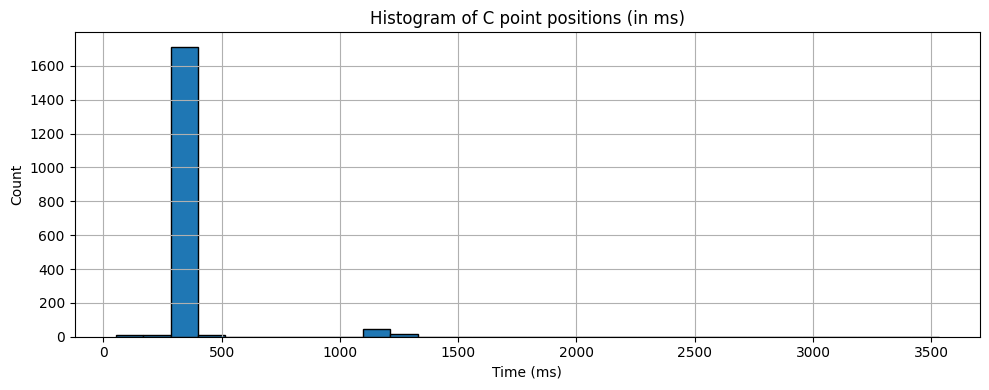

In [ ]:
# Sampling frequency
fs = 250  # Hz

# Convert C point indices to milliseconds
c_values_ms = (y_bcxo[:, 1] * 1000) / fs

plt.figure(figsize=(10, 4))
plt.hist(c_values_ms, bins=30, edgecolor='black')
plt.title("Histogram of C point positions (in ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# for c in y_bcxo:
#   print(c[1])

In [ ]:
# Umbral en muestras, 100 samples = 400 ms
threshold = 100

# Índices de segmentos con C > threshold
bad_indices = np.where(y_bcxo[:, 1] > threshold)[0]

print("Indices with large C values:", bad_indices)


Indices with large C values: [ 591  869  870  871  872  873  874  875  876  877  878  879  880  881
  882  883  884  885  886  887  888  889  890  891  892  893  894  895
  896  897  898  899  900  901  902  903  904  908  909  910  911  912
  913  924  925  926  927  928  929  930  931  932  933  934  935  936
  937  938  939  940  941  942 1667 1731 1733 1734 1748 1752 1762]


In [ ]:
def plot_bcxo_predictions(X, y_true, y_pred, indices=None, fs=250):
    """
    Plot ICG segments with predicted and true B, C, X, O labels.

    Parameters:
        X: np.ndarray of shape (n_samples, segment_len, 2) — ICG+ECG segments (use ICG only)
        y_true: np.ndarray of shape (n_samples, 4) — true label indices for B, C, X, O
        y_pred: np.ndarray of shape (n_samples, 4) — predicted label indices for B, C, X, O
        indices: list or array of indices to plot (default: first 5)
        fs: sampling frequency in Hz (for x-axis in seconds if desired)
    """
    labels = ['B', 'C', 'X', 'O']
    colors_true = ['blue', 'orange', 'green', 'red']
    colors_pred = ['blue', 'orange', 'green', 'red']

    if indices is None:
        indices = range(min(5, len(X)))

    for i in indices:
        signal = X[i, :, 0]  # ICG only
        plt.figure(figsize=(12, 4))
        plt.plot(signal, label='ICG (normalized)', color='black')

        for j, label in enumerate(labels):
            t_true = y_true[i, j]
            t_pred = y_pred[i, j]

            # Real label
            if 0 <= t_true < signal.shape[0]:
                plt.plot(t_true, signal[t_true], marker='o', color=colors_true[j],
                         label=f'True {label}', linestyle='None')

            # Predicted label
            if 0 <= t_pred < signal.shape[0]:
                plt.plot(t_pred, signal[t_pred], marker='x', color=colors_pred[j],
                         label=f'Pred {label}')

        plt.title(f"Segment {i}")
        plt.xlabel("Sample index")
        plt.ylabel("ICG amplitude (normalized)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_bcxo_predictions(X_input, y_true=y_bcxo, y_pred=predicted_b_c_x_o, indices=1)


NameError: name 'X_input' is not defined

In [ ]:
print(f"True C index for segment {i}: {y_bcxo[i, 1]}")

True C index for segment 4: 95


In [ ]:
print("Relative positions of predicted B, C, X, O points:")
print(predicted_b_c_x_o[:5])

Relative positions of predicted B, C, X, O points:
[[ 72  92 156 181]
 [ 72  92 149 178]
 [ 71  91 153 182]
 [ 74  94 147 181]
 [ 72  94 149 182]]


# Plotting the predictions on the full signal

In [ ]:
def compute_absolute_positions(predicted_relative, rpeaks_index, offset):
    """
    Convert relative B, C, X, O positions to absolute positions using the segment offset.

    Parameters:
        predicted_relative: np.array of shape (n_beats, 4)
        rpeaks_index: np.array of shape (n_beats,)
        offset: int, number of samples before R-peak in each segment

    Returns:
        np.array of shape (n_beats, 4) with absolute sample indices
    """
    n = min(len(predicted_relative), len(rpeaks_index))
    predicted_relative = predicted_relative[:n]
    rpeaks_index = rpeaks_index[:n]
    return rpeaks_index[:, np.newaxis] - offset + predicted_relative


def compute_beat_to_beat_intervals_ms(predicted_absolute, fs=250):
    """
    Compute beat-to-beat intervals (in milliseconds) for each point type.

    Input:
        predicted_absolute: np.array of shape (n_beats, 4)
        fs: Sampling frequency (Hz)

    Output:
        intervals_dict: dict of interval arrays in ms
    """
    labels = ['B', 'C', 'X', 'O']
    intervals_dict = {}
    for i, label in enumerate(labels):
        diffs = np.diff(predicted_absolute[:, i])  # in samples
        intervals_ms = diffs * 1000 / fs           # convert to ms
        intervals_dict[label] = intervals_ms
    return intervals_dict

def summarize_intervals_table(intervals_dict):
    """
    Create a summary table with mean, std, and coefficient of variation.
    """
    stats = []
    for label, intervals in intervals_dict.items():
        mean = np.mean(intervals)
        std = np.std(intervals)
        cv = std / mean * 100 if mean != 0 else 0
        stats.append([f"{label}-{label}", f"{mean:.2f}", f"{std:.2f}", f"{cv:.2f}%"])

    df = pd.DataFrame(stats, columns=["Interval", "Mean (ms)", "Std (ms)", "CV (%)"])
    display(df)

fs = 250
offset = int(0.2 * fs)  # 50 samples = 0.2s before R-peak
absolute_b_c_x_o = compute_absolute_positions(predicted_b_c_x_o, r_peaks, offset)

intervals_dict = compute_beat_to_beat_intervals_ms(absolute_b_c_x_o, fs=fs)
summarize_intervals_table(intervals_dict)

,Interval,Mean (ms),Std (ms),CV (%)
0,B-B,690.82,41.87,6.06%
1,C-C,690.80,41.91,6.07%
2,X-X,690.64,46.05,6.67%
3,O-O,690.60,58.63,8.49%


In [ ]:
def compute_rr_intervals(r_peaks, fs=250):
    """
    Computes RR intervals from a list of R-peak sample indices.

    Parameters:
        r_peaks: np.array of R-peak sample indices.
        fs: Sampling frequency in Hz.

    Returns:
        rr_intervals_ms: np.array of RR intervals in milliseconds.
    """
    # Ensure r_peaks is a sorted numpy array
    r_peaks = np.sort(np.array(r_peaks))

    # Calculate the difference between consecutive R-peaks (in samples)
    rr_intervals_samples = np.diff(r_peaks)

    # Convert to milliseconds
    rr_intervals_ms = rr_intervals_samples * 1000 / fs

    return rr_intervals_ms

rr_intervals_ms = compute_rr_intervals(r_peaks, fs=fs)

print("\nSample RR intervals (ms):")
print(rr_intervals_ms[:10])
print(f"\nMean RR interval: {np.mean(rr_intervals_ms):.2f} ms")
print(f"Std Deviation of RR intervals: {np.std(rr_intervals_ms):.2f} ms")


Sample RR intervals (ms):
[760. 772. 788. 800. 800. 768. 788. 796. 804. 768.]

Mean RR interval: 690.84 ms
Std Deviation of RR intervals: 41.50 ms


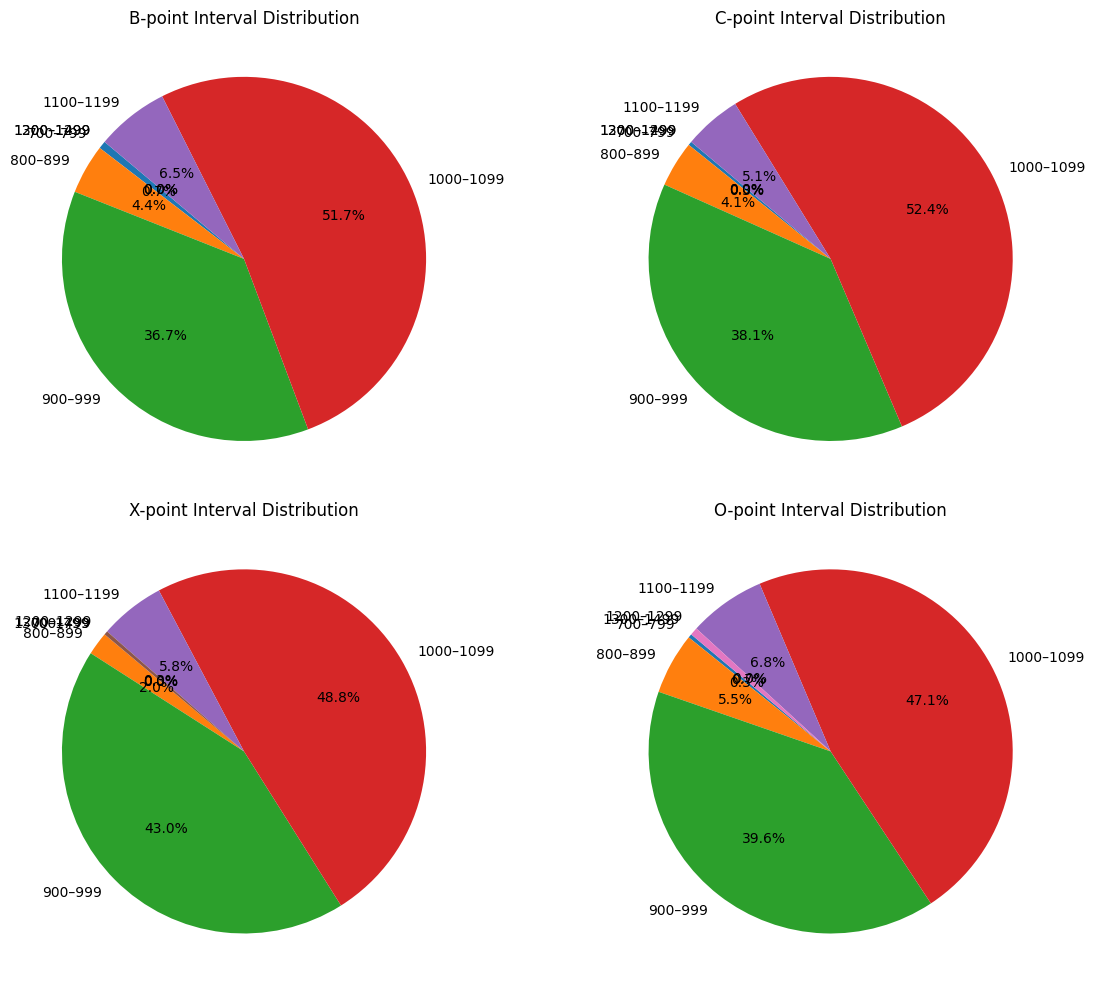

In [ ]:
def plot_interval_distribution(intervals_dict, bins=None):
    """
    Create pie charts showing the distribution of interval lengths.

    Parameters:
    - intervals_dict: dict with keys 'B', 'C', 'X', 'O', each containing an array of intervals
    - bins: list of bin edges (e.g., [700, 800, 900, 1000, 1100, 1200, 1300])
    """
    if bins is None:
        bins = [700, 800, 900, 1000, 1100, 1200, 1300, 1500]
        #bins = [1000, 750, 600, 300]


    labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, key in enumerate(['B', 'C', 'X', 'O']):
        intervals = np.array(intervals_dict[key])
        counts, _ = np.histogram(intervals, bins=bins)

        axes[idx].pie(
            counts,
            labels=labels,
            autopct='%1.1f%%',
            startangle=140
        )
        axes[idx].set_title(f"{key}-point Interval Distribution")

    plt.tight_layout()
    plt.show()

plot_interval_distribution(intervals_dict)
